# EWC (Elastic Weight Consolidation)

- Before learning a new task, measure which
weights mattered for the old tasks (the Fisher information) and add a penalty that
holds those weights near their old values. Costs no stored data only the Fisher
diagonal and a copy of the weights

## **Connect Colab**

In [4]:
import os, sys, subprocess
from getpass import getpass

REPO   = "silvergjeka22/Unified-Lifelong-Action-Learning"
BRANCH = "real-video"
ROOT   = "/content/ulal"

token = os.environ.get("GITHUB_TOKEN") or getpass("GitHub token: ")
os.environ["GITHUB_TOKEN"] = token


if os.path.isdir(os.path.join(ROOT, ".git")):
    subprocess.run(["git", "-C", ROOT, "fetch", "--depth", "1", "origin", BRANCH], check=True)
    subprocess.run(["git", "-C", ROOT, "reset", "--hard", "FETCH_HEAD"], check=True)
else:
    subprocess.run(["git", "clone", "--depth", "1", "--branch", BRANCH,
                    "https://" + token + "@github.com/" + REPO + ".git", ROOT], check=True)

if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

In [5]:
os.environ["KAGGLE_USERNAME"] = "colab"
os.environ["KAGGLE_KEY"]      = "KEY"

## **Download DATASET**

In [6]:
from src.bootstrap import setup
setup(drive=True, dataset=True)

Mounted at /content/drive
Drive mounted.
Using Colab cache for faster access to the 'ucf101-action-recognition' dataset.
ULAL_DATASET_ROOT = /kaggle/input/ucf101-action-recognition/
ULAL_OUTPUT_ROOT  = /kaggle/working/ucf101-processed/
ULAL_DATA_ROOT     = /content/UCF101
ULAL_DRIVE_PROJECT = /content/drive/MyDrive/apai
Setup complete — no config.py edit, no kernel restart.


In [7]:
# imports
%run /content/ulal/src/imports.py
set_seed(cfg.SEED)

ULAL_ROOT : /content/ulal
Device    : cuda
Classes   : base=10 task1=5 task2=5


42

## **Preprocess data**

Group-disjoint clips for all three tasks

In [8]:
base_split  = build_group_split(cfg.SELECTED_CLASSES, train_groups=18, val_groups=3)
task1_split = build_group_split(cfg.TASK_1,           train_groups=18, val_groups=3)
task2_split = build_group_split(cfg.TASK_2,           train_groups=18, val_groups=3)

In [9]:
# BASE  (max_samples caps TRAIN clips/class via cfg.MAX_SAMPLES; None = full data, val/test untouched)
preprocess_group_split(base_split, cfg.SELECTED_CLASSES, output_root=cfg.BASE_ROOT, max_samples=cfg.MAX_SAMPLES)


--- Preprocessing (group-disjoint) ---
To  : /content/UCF101/grouped_base
Classes: 10

Processing split: train



Processing split: val



Processing split: test



Done. Clips ready at: /content/UCF101/grouped_base


In [10]:
# TASK 1  (same TRAIN-only cap via cfg.MAX_SAMPLES)
preprocess_group_split(task1_split, cfg.TASK_1, output_root=cfg.TASK1_ROOT, max_samples=cfg.MAX_SAMPLES)


--- Preprocessing (group-disjoint) ---
To  : /content/UCF101/grouped_task1
Classes: 5

Processing split: train



Processing split: val



Processing split: test



Done. Clips ready at: /content/UCF101/grouped_task1


In [11]:
# TASK 2  (same TRAIN-only cap via cfg.MAX_SAMPLES)
preprocess_group_split(task2_split, cfg.TASK_2, output_root=cfg.TASK2_ROOT, max_samples=cfg.MAX_SAMPLES)


--- Preprocessing (group-disjoint) ---
To  : /content/UCF101/grouped_task2
Classes: 5

Processing split: train



Processing split: val



Processing split: test



Done. Clips ready at: /content/UCF101/grouped_task2


In [12]:
cfg.SELECTED_CLASSES

['PlayingTabla',
 'PommelHorse',
 'JumpingJack',
 'PushUps',
 'PoleVault',
 'HorseRace',
 'HighJump',
 'Drumming',
 'HorseRiding',
 'Diving']

In [13]:
print(cfg.SELECTED_CLASSES + cfg.TASK_1)

['PlayingTabla', 'PommelHorse', 'JumpingJack', 'PushUps', 'PoleVault', 'HorseRace', 'HighJump', 'Drumming', 'HorseRiding', 'Diving', 'ApplyEyeMakeup', 'ApplyLipstick', 'Archery', 'BabyCrawling', 'BalanceBeam']


In [14]:
ALL_CLASSES_LIST = cfg.SELECTED_CLASSES + cfg.TASK_1
class_to_idx     = {cls_name: i for i, cls_name in enumerate(ALL_CLASSES_LIST)}
print(class_to_idx)

{'PlayingTabla': 0, 'PommelHorse': 1, 'JumpingJack': 2, 'PushUps': 3, 'PoleVault': 4, 'HorseRace': 5, 'HighJump': 6, 'Drumming': 7, 'HorseRiding': 8, 'Diving': 9, 'ApplyEyeMakeup': 10, 'ApplyLipstick': 11, 'Archery': 12, 'BabyCrawling': 13, 'BalanceBeam': 14}


## **Create Loaders**

EWC needs the OLD task's train set (for the Fisher) and its val set (to watch retention), so base train / val loaders are built too.

In [15]:
base_train = UCF101Clips(os.path.join(cfg.BASE_ROOT, "train"), class_to_idx=class_to_idx)
base_val   = UCF101Clips(os.path.join(cfg.BASE_ROOT, "val"),   class_to_idx=class_to_idx)
base_test  = UCF101Clips(os.path.join(cfg.BASE_ROOT, "test"),  class_to_idx=class_to_idx)

base_train_loader = DataLoader(base_train, batch_size=cfg.BATCH_SIZE, shuffle=True,  num_workers=2)
base_val_loader   = DataLoader(base_val,   batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=2)
base_test_loader  = DataLoader(base_test,  batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=2)

task1_train = UCF101Clips(os.path.join(cfg.TASK1_ROOT, "train"), class_to_idx=class_to_idx)
task1_val   = UCF101Clips(os.path.join(cfg.TASK1_ROOT, "val"),   class_to_idx=class_to_idx)
task1_test  = UCF101Clips(os.path.join(cfg.TASK1_ROOT, "test"),  class_to_idx=class_to_idx)

task1_train_loader = DataLoader(task1_train, batch_size=cfg.BATCH_SIZE, shuffle=True,  num_workers=2)
task1_val_loader   = DataLoader(task1_val,   batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=2)
task1_test_loader  = DataLoader(task1_test,  batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=2)

combined_test        = ConcatDataset([base_test, task1_test])
combined_test_loader = DataLoader(combined_test, batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=2)

## **Upload Model**

Load the ResNet50 teacher from notebook 2, then grow the head to cover Task 1.

In [16]:
model = ResNet50LSTM(num_classes=len(cfg.SELECTED_CLASSES)).to(device)
model.load_state_dict(torch.load(cfg.RESNET50_PATH, map_location=device))
model = unfreeze_all(model)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 187MB/s]


In [17]:
model = expand_classifier(model, len(ALL_CLASSES_LIST))
model = unfreeze_all(model).to(device)

In [18]:
snapshots = []
results_baseline = evaluate_all_tasks(model, device, base_test_loader, [task1_test_loader], [combined_test_loader])
snapshots.append(results_baseline)

  base             -> Acc=0.9387  Loss=0.1979
  task1_only        -> Acc=0.0000  Loss=4.4398
  combined_t1       -> Acc=0.6180  Loss=1.6470


In [19]:
print(f"classifier: in={model.fc.in_features}  out={model.fc.out_features}")

classifier: in=256  out=15


## **Task One**

Anchor and Fisher come from the base task, then Task 1 is trained with the EWC penalty. The printout shows new-task and base val accuracy each epoch.

In [20]:
star_base   = theta_star(model)
fisher_base = get_fisher(base_train_loader, model, device)

In [21]:
cfg.EWC_LAMBDA

2500.0

In [22]:
set_seed(cfg.SEED)
forget_hist = []
track1 = {"Base": base_test_loader, "Task 1": task1_test_loader}
train_task1 = train_ewc(model, task1_train_loader, task1_val_loader, base_val_loader,
                        star_base, fisher_base, device,
                        num_epochs=cfg.CL_EPOCHS, lr=cfg.CL_LR, ewc_lambda=cfg.EWC_LAMBDA,
                        track_loaders=track1, track_history=forget_hist)

Epoch [1/5] | Train 0.1887 | CE 2.415 | EWC 1.927 (80% of CE) | New Val 0.3425 | Old Val 0.8485


Epoch [2/5] | Train 0.5770 | CE 1.474 | EWC 1.572 (107% of CE) | New Val 0.5479 | Old Val 0.8606


Epoch [3/5] | Train 0.7505 | CE 1.106 | EWC 1.514 (137% of CE) | New Val 0.6575 | Old Val 0.8303


Epoch [4/5] | Train 0.8134 | CE 0.958 | EWC 1.608 (168% of CE) | New Val 0.6986 | Old Val 0.7818


Epoch [5/5] | Train 0.8503 | CE 0.852 | EWC 1.593 (187% of CE) | New Val 0.7260 | Old Val 0.8000


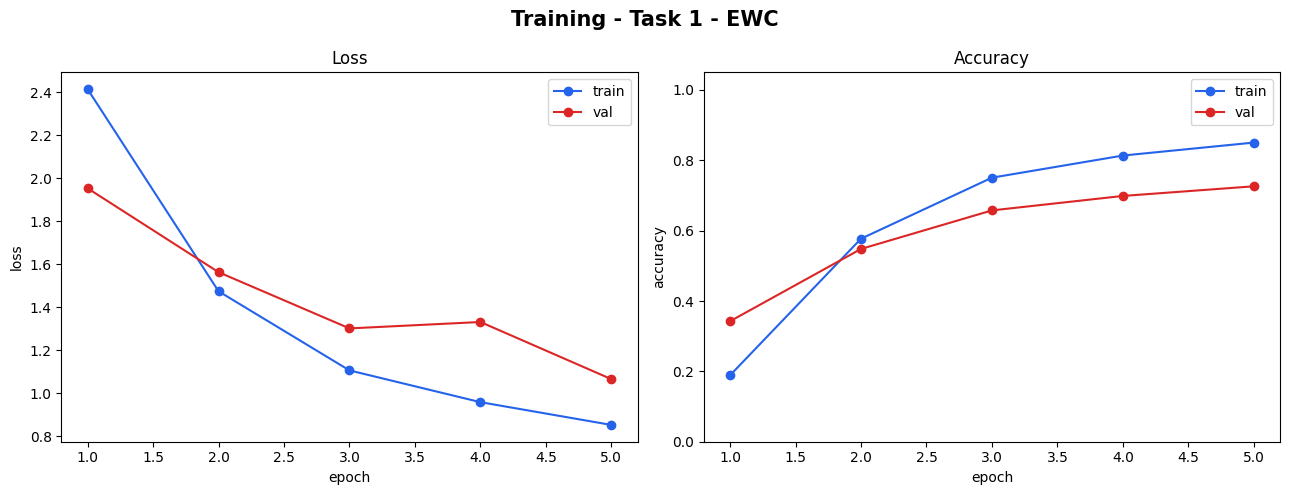

In [23]:
plot_training_results(train_task1, task_name="Task 1 - EWC")

In [24]:
results_after_t1 = evaluate_all_tasks(model, device, base_test_loader, [task1_test_loader], [combined_test_loader])
snapshots.append(results_after_t1)

  base             -> Acc=0.8066  Loss=0.6726
  task1_only        -> Acc=0.7909  Loss=0.9182
  combined_t1       -> Acc=0.8012  Loss=0.7565


Test Accuracy: 0.8012


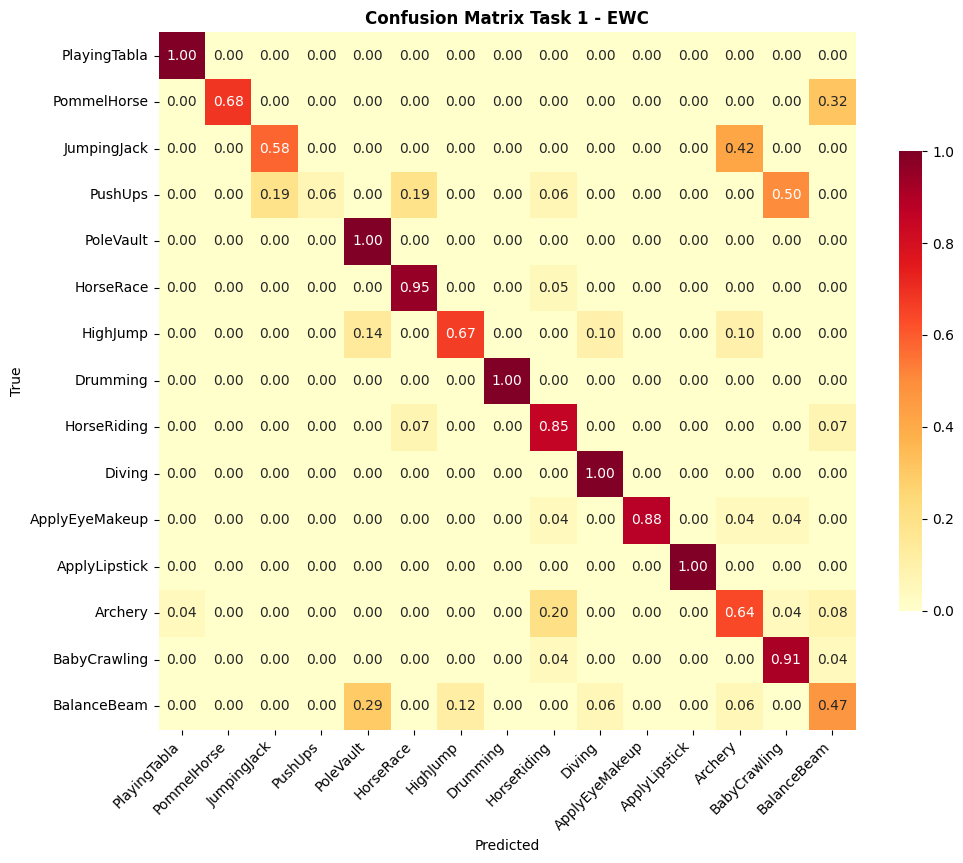

In [25]:
_, all_preds, all_labels = test_model(model, combined_test_loader, device)
plot_confusion_matrix(all_labels, all_preds, num_classes=len(ALL_CLASSES_LIST),
                      classes_list=ALL_CLASSES_LIST, name="Task 1 - EWC")

In [26]:
print_detailed_metrics(all_labels, all_preds, num_classes=len(ALL_CLASSES_LIST),
                       classes_list=ALL_CLASSES_LIST,
                       split_old=(0, len(cfg.SELECTED_CLASSES)),
                       split_new=(len(cfg.SELECTED_CLASSES), len(ALL_CLASSES_LIST)))


METRICS FOR 15 CLASSES
  Accuracy : 0.8012
  F1-Score : 0.7851

PER-CLASS REPORT
                precision    recall  f1-score   support

  PlayingTabla       0.94      1.00      0.97        17
   PommelHorse       1.00      0.68      0.81        19
   JumpingJack       0.79      0.58      0.67        19
       PushUps       1.00      0.06      0.12        16
     PoleVault       0.76      1.00      0.86        25
     HorseRace       0.79      0.95      0.86        20
      HighJump       0.88      0.67      0.76        21
      Drumming       1.00      1.00      1.00        25
   HorseRiding       0.72      0.85      0.78        27
        Diving       0.88      1.00      0.94        23
ApplyEyeMakeup       1.00      0.88      0.94        25
 ApplyLipstick       1.00      1.00      1.00        20
       Archery       0.57      0.64      0.60        25
  BabyCrawling       0.68      0.91      0.78        23
   BalanceBeam       0.42      0.47      0.44        17

      accuracy      

## **Task 2**

In [27]:
ALL_CLASSES_LIST = cfg.SELECTED_CLASSES + cfg.TASK_1 + cfg.TASK_2
class_to_idx     = {cls_name: i for i, cls_name in enumerate(ALL_CLASSES_LIST)}
print(class_to_idx)

{'PlayingTabla': 0, 'PommelHorse': 1, 'JumpingJack': 2, 'PushUps': 3, 'PoleVault': 4, 'HorseRace': 5, 'HighJump': 6, 'Drumming': 7, 'HorseRiding': 8, 'Diving': 9, 'ApplyEyeMakeup': 10, 'ApplyLipstick': 11, 'Archery': 12, 'BabyCrawling': 13, 'BalanceBeam': 14, 'BoxingPunchingBag': 15, 'BoxingSpeedBag': 16, 'BrushingTeeth': 17, 'CliffDiving': 18, 'CricketBowling': 19}


In [28]:
task2_train = UCF101Clips(os.path.join(cfg.TASK2_ROOT, "train"), class_to_idx=class_to_idx)
task2_val   = UCF101Clips(os.path.join(cfg.TASK2_ROOT, "val"),   class_to_idx=class_to_idx)
task2_test  = UCF101Clips(os.path.join(cfg.TASK2_ROOT, "test"),  class_to_idx=class_to_idx)

task2_train_loader = DataLoader(task2_train, batch_size=cfg.BATCH_SIZE, shuffle=True,  num_workers=2)
task2_val_loader   = DataLoader(task2_val,   batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=2)
task2_test_loader  = DataLoader(task2_test,  batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=2)

combined_test2        = ConcatDataset([base_test, task1_test, task2_test])
combined_test_loader2 = DataLoader(combined_test2, batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=2)

In [29]:
model = expand_classifier(model, len(ALL_CLASSES_LIST))
model = unfreeze_all(model).to(device)

Now the old task is base + Task 1, so the anchor and Fisher are measured over both.

In [30]:
old_train        = ConcatDataset([base_train, task1_train])
old_train_loader = DataLoader(old_train, batch_size=cfg.BATCH_SIZE, shuffle=True, num_workers=2)
old_val          = ConcatDataset([base_val, task1_val])
old_val_loader   = DataLoader(old_val, batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=2)

star_t1   = theta_star(model)
fisher_t1 = get_fisher(old_train_loader, model, device)

In [31]:
results_baseline_t2 = evaluate_all_tasks(model, device, base_test_loader,
                                         [task1_test_loader, task2_test_loader],
                                         [combined_test_loader, combined_test_loader2])

  base             -> Acc=0.8962  Loss=0.5118
  task1_only        -> Acc=0.7182  Loss=1.1169
  task2_only        -> Acc=0.0000  Loss=3.9309
  combined_t1       -> Acc=0.8354  Loss=0.7185
  combined_t2       -> Acc=0.6128  Loss=1.5747


In [32]:
set_seed(cfg.SEED)
track2 = {"Base": base_test_loader, "Task 1": task1_test_loader, "Task 2": task2_test_loader}
train_task2 = train_ewc(model, task2_train_loader, task2_val_loader, old_val_loader,
                        star_t1, fisher_t1, device,
                        num_epochs=cfg.CL_EPOCHS, lr=cfg.CL_LR, ewc_lambda=cfg.EWC_LAMBDA,
                        track_loaders=track2, track_history=forget_hist)

Epoch [1/5] | Train 0.0060 | CE 3.191 | EWC 1.749 (55% of CE) | New Val 0.0000 | Old Val 0.7941


Epoch [2/5] | Train 0.0696 | CE 2.596 | EWC 1.528 (59% of CE) | New Val 0.1412 | Old Val 0.7773


Epoch [3/5] | Train 0.2704 | CE 2.219 | EWC 1.432 (65% of CE) | New Val 0.3059 | Old Val 0.7605


Epoch [4/5] | Train 0.3936 | CE 2.011 | EWC 1.404 (70% of CE) | New Val 0.3882 | Old Val 0.7269


Epoch [5/5] | Train 0.4811 | CE 1.925 | EWC 1.426 (74% of CE) | New Val 0.3647 | Old Val 0.6723


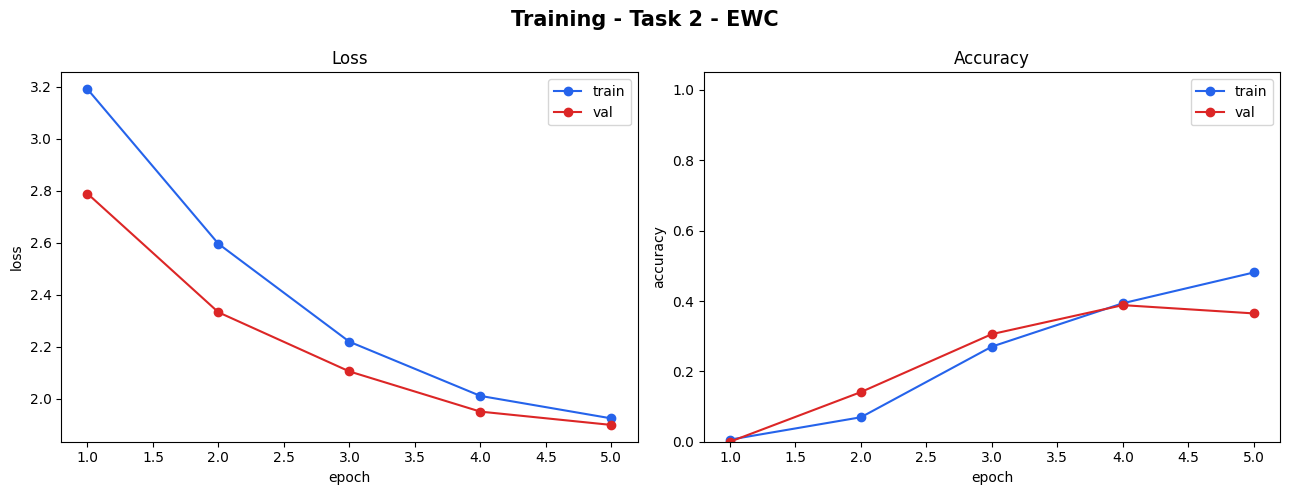

In [33]:
plot_training_results(train_task2, task_name="Task 2 - EWC")

In [34]:
results_after_t2 = evaluate_all_tasks(model, device, base_test_loader,
                                      [task1_test_loader, task2_test_loader],
                                      [combined_test_loader, combined_test_loader2])
snapshots.append(results_after_t2)

  base             -> Acc=0.7689  Loss=1.1107
  task1_only        -> Acc=0.6000  Loss=1.6915
  task2_only        -> Acc=0.3675  Loss=2.0414
  combined_t1       -> Acc=0.7112  Loss=1.3091
  combined_t2       -> Acc=0.6196  Loss=1.5043


Test Accuracy: 0.6196


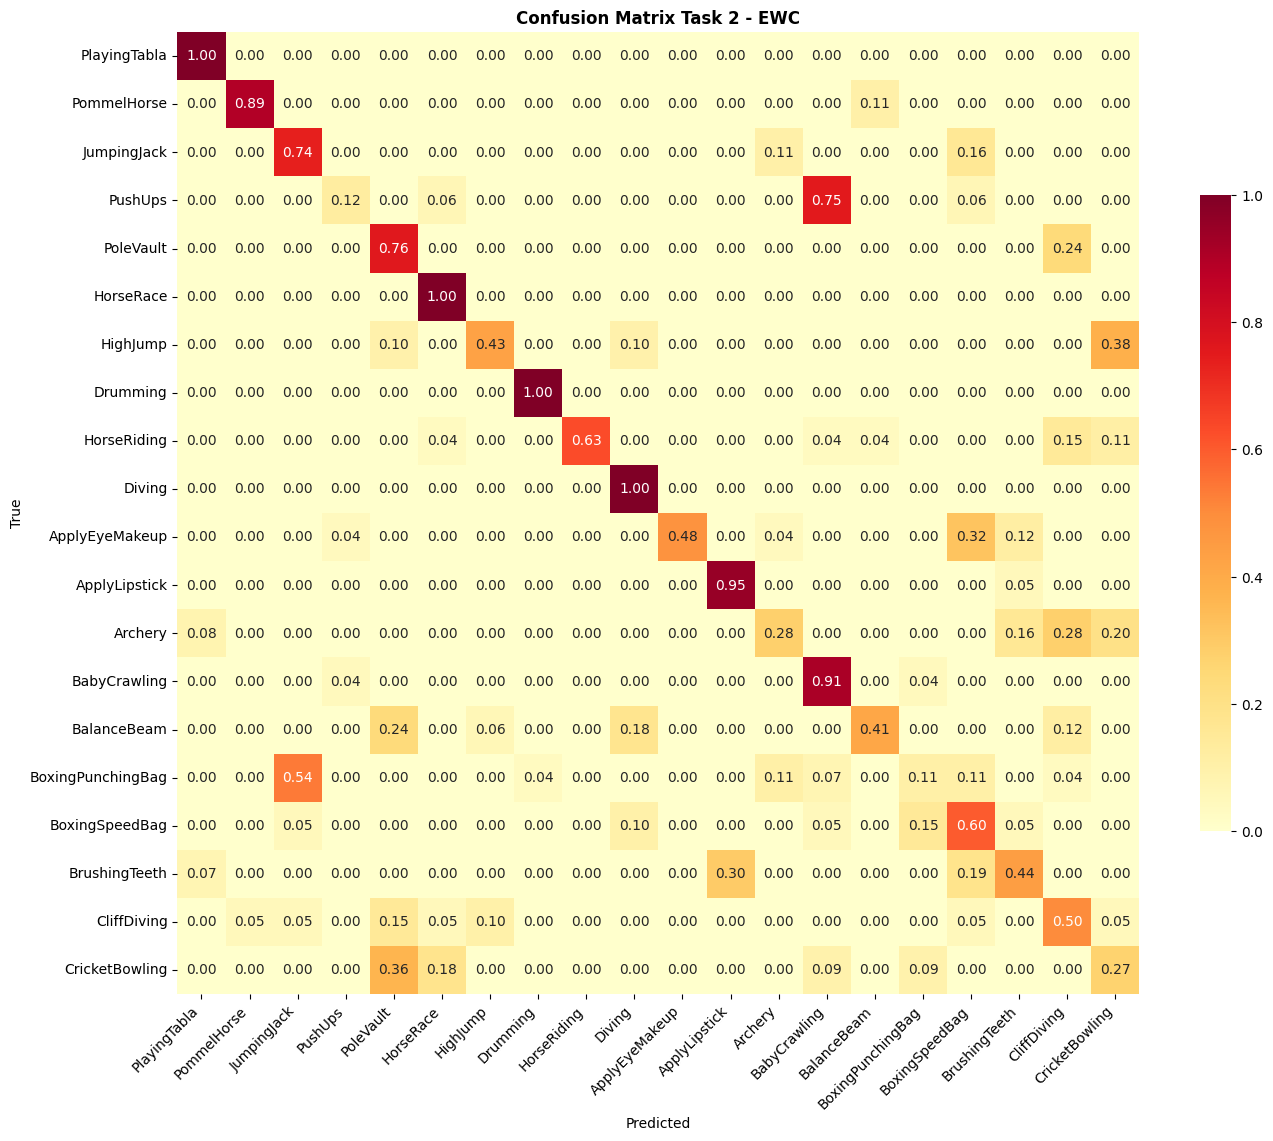

In [35]:
_, all_preds, all_labels = test_model(model, combined_test_loader2, device)
plot_confusion_matrix(all_labels, all_preds, num_classes=len(ALL_CLASSES_LIST),
                      classes_list=ALL_CLASSES_LIST, name="Task 2 - EWC")

In [36]:
split_new = len(cfg.SELECTED_CLASSES) + len(cfg.TASK_1)
print_detailed_metrics(all_labels, all_preds, num_classes=len(ALL_CLASSES_LIST),
                       classes_list=ALL_CLASSES_LIST,
                       split_old=(0, split_new),
                       split_new=(split_new, len(ALL_CLASSES_LIST)))


METRICS FOR 20 CLASSES
  Accuracy : 0.6196
  F1-Score : 0.5988

PER-CLASS REPORT
                   precision    recall  f1-score   support

     PlayingTabla       0.81      1.00      0.89        17
      PommelHorse       0.94      0.89      0.92        19
      JumpingJack       0.45      0.74      0.56        19
          PushUps       0.50      0.12      0.20        16
        PoleVault       0.53      0.76      0.62        25
        HorseRace       0.74      1.00      0.85        20
         HighJump       0.75      0.43      0.55        21
         Drumming       0.96      1.00      0.98        25
      HorseRiding       1.00      0.63      0.77        27
           Diving       0.77      1.00      0.87        23
   ApplyEyeMakeup       1.00      0.48      0.65        25
    ApplyLipstick       0.70      0.95      0.81        20
          Archery       0.54      0.28      0.37        25
     BabyCrawling       0.54      0.91      0.68        23
      BalanceBeam       0.70    

## **Forgetting**

In [37]:
snapshots

[{'base': {'accuracy': 0.9386792452830188, 'loss': 0.19791975269480697},
  'task1_only': {'accuracy': 0.0, 'loss': 4.439766710454768},
  'combined_t1': {'accuracy': 0.6180124223602484, 'loss': 1.646997917813729}},
 {'base': {'accuracy': 0.8066037735849056, 'loss': 0.672579971405695},
  'task1_only': {'accuracy': 0.7909090909090909, 'loss': 0.9182180361314254},
  'combined_t1': {'accuracy': 0.8012422360248447, 'loss': 0.7564935900779984}},
 {'base': {'accuracy': 0.7688679245283019, 'loss': 1.110734742767406},
  'task1_only': {'accuracy': 0.6, 'loss': 1.6914770299738104},
  'task2_only': {'accuracy': 0.36752136752136755, 'loss': 2.0414411012942972},
  'combined_t1': {'accuracy': 0.7111801242236024, 'loss': 1.3091249873179087},
  'combined_t2': {'accuracy': 0.6195899772209568, 'loss': 1.504298077628933}}]

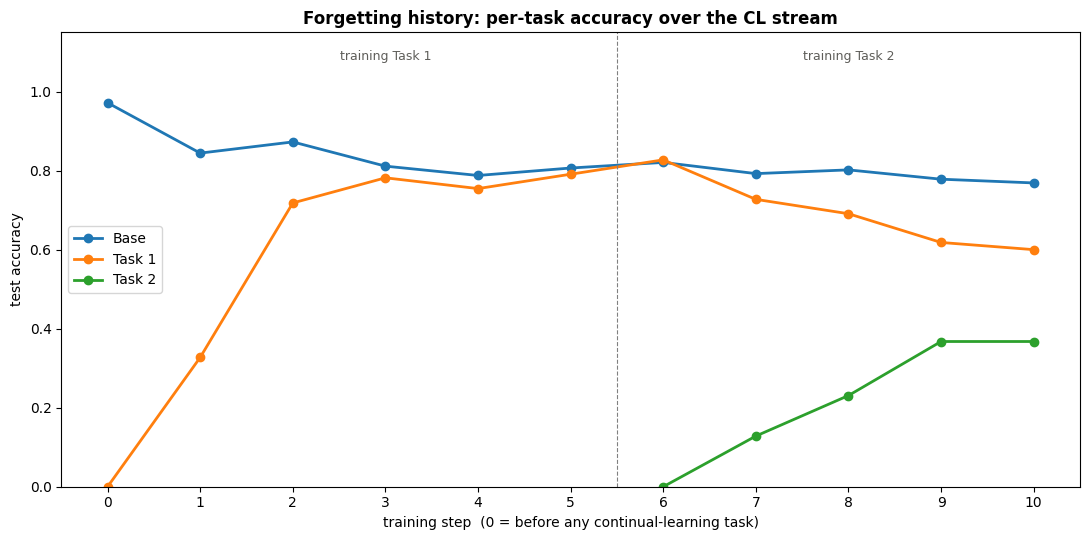

In [38]:
plot_forgetting_history(forget_hist, epochs_per_task=cfg.CL_EPOCHS)

## **Save**

In [39]:
os.makedirs(cfg.RESULTS_DIR, exist_ok=True)
payload = {"arm": "ewc", "classes": ALL_CLASSES_LIST, "snapshots": snapshots}
with open(f"{cfg.RESULTS_DIR}/stage3_ewc.json", "w") as f:
    json.dump(payload, f, indent=2)
print(f"saved -> {cfg.RESULTS_DIR}/stage3_ewc.json")

saved -> /content/drive/MyDrive/apai/results/stage3_ewc.json
